In [17]:
import numpy as np

"""
Exercise 4: NumPy Array Operations
Complete the following tasks using NumPy.
"""

# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
# (5 points)
# TODO: Create the matrix described above
# Hint: Use np.ones and array slicing
border_matrix = np.ones((5, 5))
border_matrix[1:-1, 1:-1] = 0
print("The 5x5 matrix\n",border_matrix, "\n\n")

# Task 2: Normalize a random array
# (5 points)
np.random.seed(42)
random_data = np.random.randn(100, 3)
# TODO: Normalize each column to have mean=0 and std=1
# Calculating the mean of each column
mean = np.mean(random_data, axis=0)

# Calculating the standard deviation of each column
std = np.std(random_data, axis=0)

# Normalize the data
normalized_data = (random_data - mean) / std
print("Normalizing each column to have mean=0 and std=1/n",normalized_data)

# Task 3: Implement linear regression solution using normal equation
# (10 points)
# Given X (features) and y (target), compute theta
# theta = (X^T X)^(-1) X^T y
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
# TODO: Calculate theta_hat using the normal equation
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
# TODO: Print the estimated coefficients and compare with true_theta
# Comparison of the results
print("\n\nEstimated coefficients:\n", theta_hat)
print("\nTrue coefficients:\n", true_theta)
print("\nDifference:\n", theta_hat - true_theta)


The 5x5 matrix
 [[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]] 


Normalizing each column to have mean=0 and std=1/n [[ 4.93439239e-01  4.61603061e-02  5.17340053e-01]
 [ 1.74402998e+00 -5.22690072e-02 -2.79011884e-01]
 [ 1.81249029e+00  9.75852610e-01 -4.91538532e-01]
 [ 5.49303576e-01 -2.87606868e-01 -4.88156860e-01]
 [ 1.83017852e-01 -1.77587837e+00 -1.62529439e+00]
 [-7.96980164e-01 -8.51575049e-01  2.16218628e-01]
 [-1.21826859e+00 -1.26163023e+00  1.25601706e+00]
 [-3.86933017e-01  2.57404552e-01 -1.35421958e+00]
 [-7.75162723e-01  3.01948517e-01 -1.10699945e+00]
 [ 3.45978124e-01 -4.28463047e-01 -3.30989813e-01]
 [-8.45013279e-01  2.08943513e+00 -7.97583137e-02]
 [-1.40066567e+00  1.03242274e+00 -1.17007910e+00]
 [ 1.42686307e-01 -1.82349718e+00 -1.26701701e+00]
 [ 1.28061139e-01  9.46117052e-01  8.71885533e-02]
 [-2.52739338e-01 -1.20992939e-01 -1.40278120e+00]
 [-9.88966824e-01 -2.84754328e-01  8.87088163e-01]
 [ 3.06888192e-01 -1.62

In [47]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration (10 points)
# TODO: Display basic information about the dataset
# Display basic information about the dataset
print("Dataset Information:")
print(df.info())

# Display first 5 rows
print("\nFirst 5 Rows:")
print(df.head())

# TODO: Identify and count missing values
# Count missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())

# TODO: Fill missing exam_score with the mean score for the student's major
major_means = df.groupby('major')['exam_score'].transform('mean')

# Filling NaN values using these means
df['exam_score'] = df['exam_score'].fillna(major_means)
print("\nMissing Values after filling:")
print(df.isnull().sum())

# TODO: Fill missing hours_studied with the median for the student's year
year_medians = df.groupby('year')['hours_studied'].transform('median')

# Filling NaN values using these medians
df['hours_studied'] = df['hours_studied'].fillna(year_medians)
print("\nMissing hours_studied after filling:")
print(df.isnull().sum())




# Task 2: Analysis (10 points)
# TODO: Calculate and display the average exam_score by major
avg_by_major = df.groupby('major')['exam_score'].mean()
print("\nAverage exam_score by major:")
print(avg_by_major)

# TODO: Find the major with the highest average exam_score
avg_by_major = df.groupby('major')['exam_score'].mean()
highest_major = avg_by_major.idxmax()  # Get index (major name) with max value
highest_score = avg_by_major.max()     # Get the actual max value
print("\nMajor with the highest average exam_score:")
print(f"{highest_major} with an average score of {highest_score:.2f}")

# TODO: Calculate the correlation between hours_studied and exam_score
correlation = df['hours_studied'].corr(df['exam_score'])
print("\nCorrelation between hours_studied and exam_score:", correlation)

# TODO: Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
bins = [0, 70, 80, 90, 100]
labels = ['Needs Improvement', 'Average', 'Good', 'Excellent']
df['performance'] = pd.cut(df['exam_score'], bins=bins, labels=labels)
print("\nThe New column 'performance' with categories:")
print(df[['student_id', 'exam_score', 'performance']])

# Task 3: Advanced Analysis (10 points)
# TODO: For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied
stats = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_score=('exam_score', 'mean'),
    avg_hours=('hours_studied', 'mean')
)
print("\nAdvanced Analysis:")
print(stats)
# TODO: Identify top 5 students based on exam_score (handle ties appropriately)
top_5students = df.nlargest(5, 'exam_score')
print("\nTop 5 students based on exam_score:")
print(top_5students[['student_id', 'exam_score']])

# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)
pivot = df.pivot_table(index='major', columns='year', values='exam_score', aggfunc='mean')
print("\nThe table for average exam_score by majorand year:")
print(pivot)


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None

First 5 Rows:
   student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
2        1002       CS     3   77.930725                      9       7.829556
3        1003  Physics     1   67.856486                     

/tmp/ipykernel_25039/39173489.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='major', y='exam_score', ax=ax2, palette='Set2')


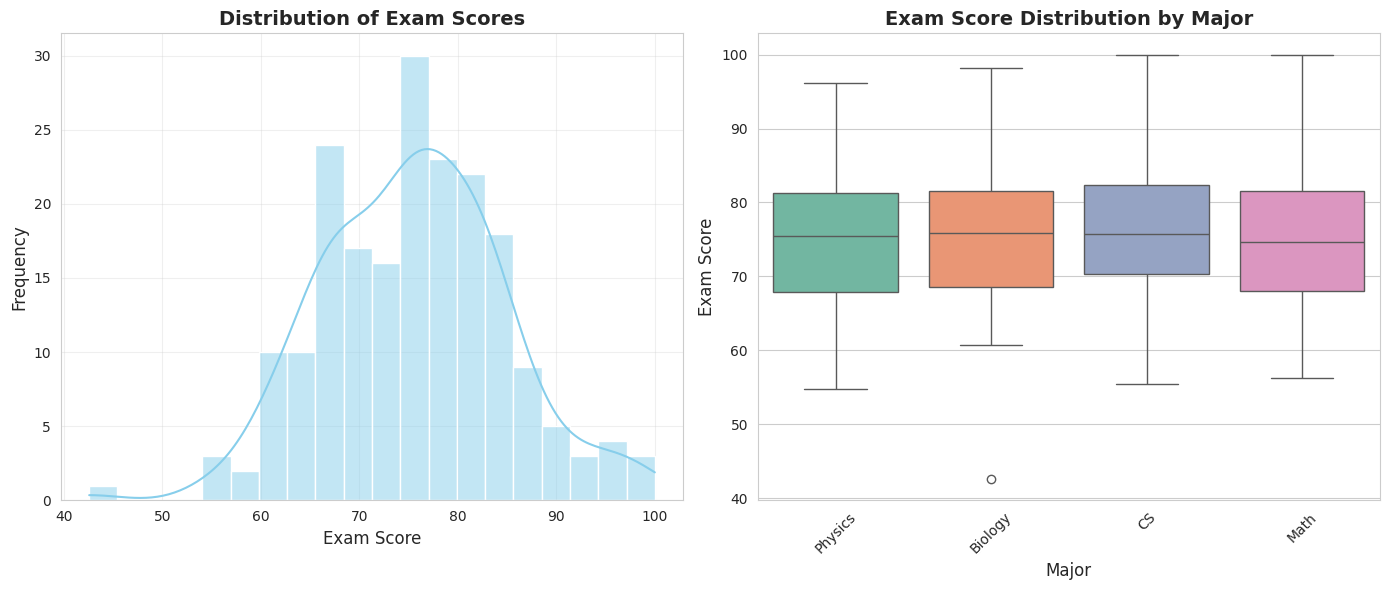

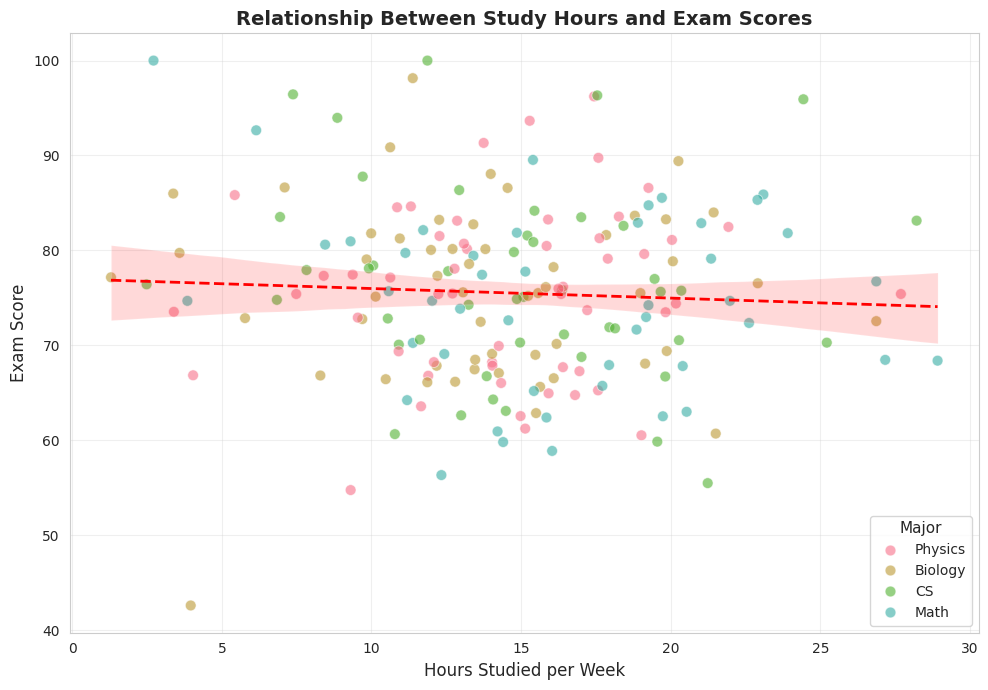

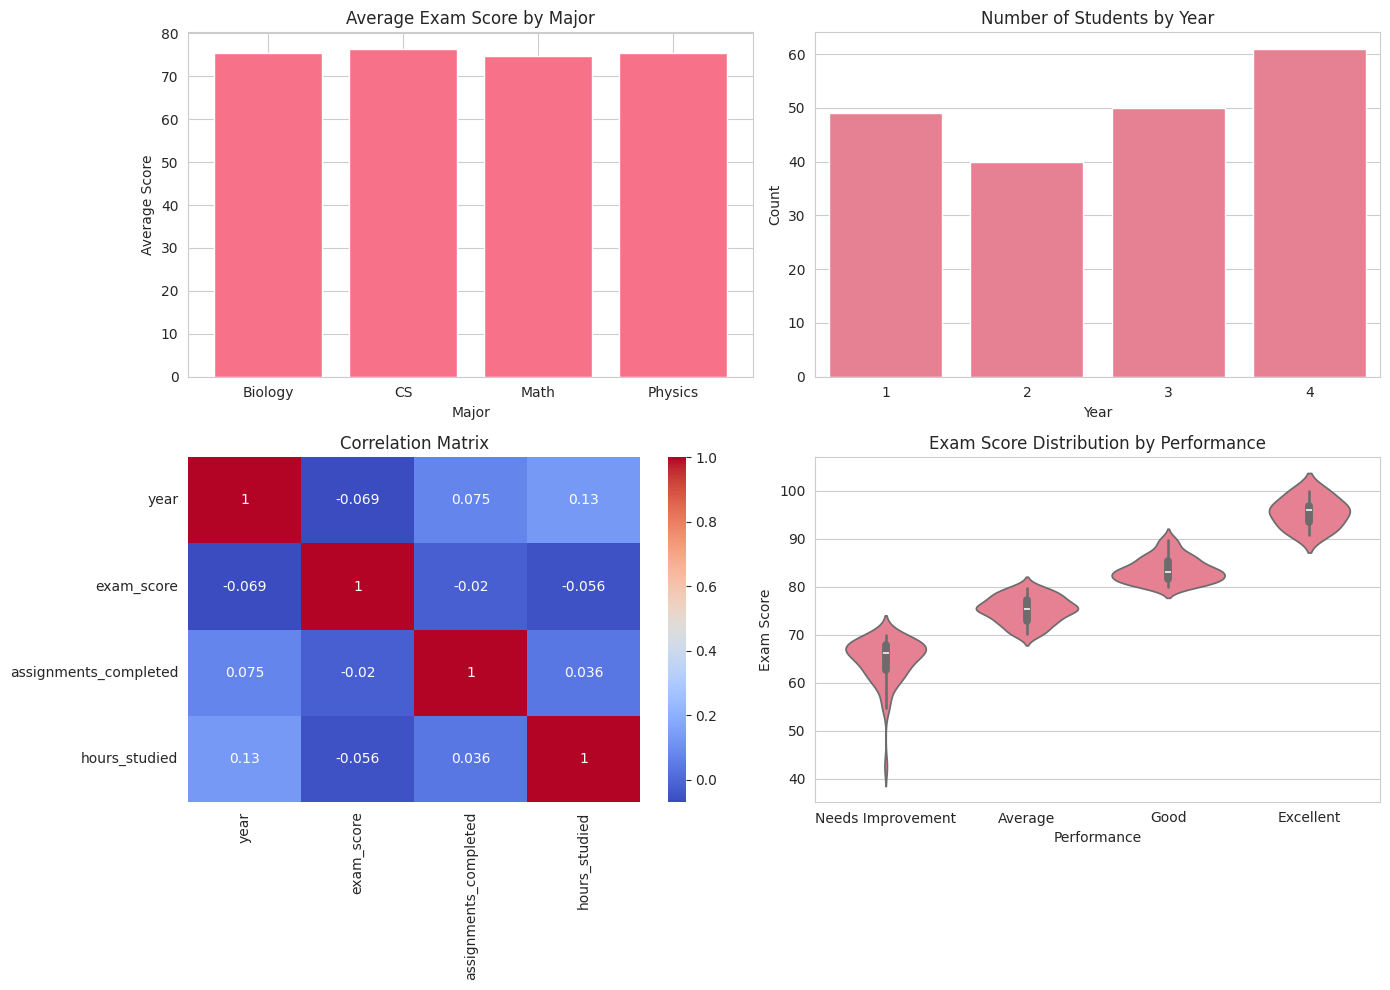

In [65]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import matplotlib.pyplot as plt
import seaborn as sns

# Continue using the df from Exercise 5

# Task 1: Distribution Visualization (8 points)
# TODO: Create a figure with 2 subplots side by side
#       Left: Histogram of exam scores with KDE overlay
#       Right: Box plot of exam scores by major
sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
# TODO: Add appropriate titles, labels, and styling
# Left: Histogram with KDE
sns.histplot(data=df, x='exam_score', kde=True, ax=ax1, color='skyblue', bins=20)
ax1.set_title('Distribution of Exam Scores', fontsize=14, fontweight='bold')
ax1.set_xlabel('Exam Score', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.grid(True, alpha=0.3)

# Right: Box plot by major
sns.boxplot(data=df, x='major', y='exam_score', ax=ax2, palette='Set2')
ax2.set_title('Exam Score Distribution by Major', fontsize=14, fontweight='bold')
ax2.set_xlabel('Major', fontsize=12)
ax2.set_ylabel('Exam Score', fontsize=12)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Task 2: Relationship Visualization (8 points)
# TODO: Create a scatter plot of hours_studied vs exam_score
# TODO: Color points by major
# TODO: Add a regression line
# TODO: Include appropriate legends, titles, and axis labels
plt.figure(figsize=(10, 7))

# Scatter plot colored by major
scatter = sns.scatterplot(data=df, x='hours_studied', y='exam_score',
                           hue='major', alpha=0.6, s=60)

# Add regression line for overall trend
sns.regplot(data=df, x='hours_studied', y='exam_score',
            scatter=False, color='red', line_kws={'linewidth': 2, 'linestyle': '--'})

plt.title('Relationship Between Study Hours and Exam Scores', fontsize=14, fontweight='bold')
plt.xlabel('Hours Studied per Week', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.legend(title='Major', loc='lower right', title_fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Task 3: Advanced Dashboard (9 points)
# TODO: Create a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major
#       2. Count plot: Number of students by year
#       3. Heat map: Correlation matrix of numerical columns
#       4. Violin plot: Exam score distribution by performance category
# Create 2x2 dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Average exam score by major

average_scores = df.groupby('major')['exam_score'].mean()

axes[0, 0].bar(
    average_scores.index,
    average_scores.values
)

axes[0, 0].set_title("Average Exam Score by Major")
axes[0, 0].set_xlabel("Major")
axes[0, 0].set_ylabel("Average Score")


# 2. Number of students by year

sns.countplot(
    data=df,
    x='year',
    ax=axes[0, 1]
)

axes[0, 1].set_title("Number of Students by Year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Count")


# 3. Correlation Heatmap

correlation_matrix = df[
    ['year',
     'exam_score',
     'assignments_completed',
     'hours_studied']
].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    ax=axes[1, 0]
)

axes[1, 0].set_title("Correlation Matrix")


# 4. Violin Plot

sns.violinplot(
    data=df,
    x='performance',
    y='exam_score',
    ax=axes[1, 1]
)

axes[1, 1].set_title("Exam Score Distribution by Performance")
axes[1, 1].set_xlabel("Performance")
axes[1, 1].set_ylabel("Exam Score")


# TODO: Adjust layout, add titles, and ensure readability

# Adjust spacing
plt.tight_layout()

# Display dashboard
plt.show()

CLV Statistics:
Mean CLV: $743.76
Median CLV: $712.26
Max CLV: $1645.71
Min CLV: $0.00

Age Group Distribution:
age_group
18-25     81
26-35     73
36-50    160
51-70    186
Name: count, dtype: int64

TODO3: Statistics by Age Group:
           num_customers    avg_income     avg_CLV      total_CLV
age_group                                                        
18-25                 81  50634.018330  718.371170   58188.064760
26-35                 73  48747.148046  747.738562   54584.915035
36-50                160  48516.895668  732.796612  117247.457917
51-70                186  50713.163384  762.693498  141860.990683

Top 10% CLV Threshold: $1222.94
Number of customers in top 10%: 50
Total CLV from top 10%: $69944.40
Percentage of total CLV: 18.8%

TODO4: Top 10 Customers by CLV:
     age age_group        income  purchase_frequency  avg_purchase_value  \
426   42     36-50  68713.567863                   8          154.285448   
213   41     36-50  45580.608009                   7 

/tmp/ipykernel_25039/1808364120.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_stats = customers.groupby('age_group').agg(


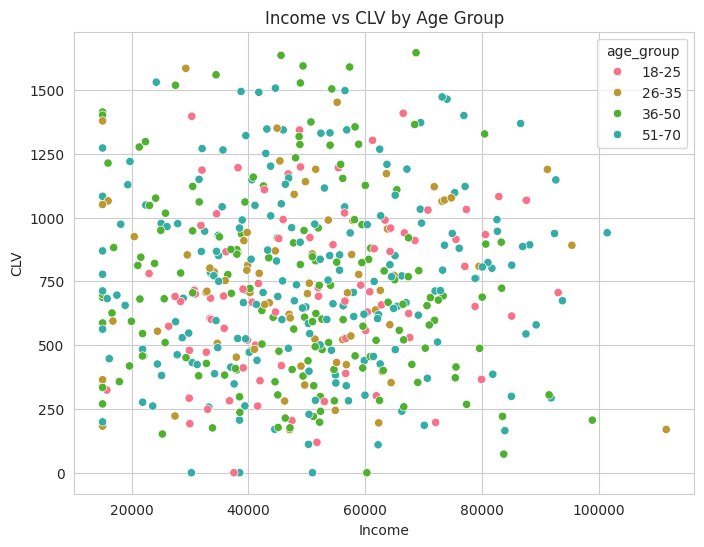

/tmp/ipykernel_25039/1808364120.py:107: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_clv_by_age = customers.groupby('age_group')['CLV'].mean()


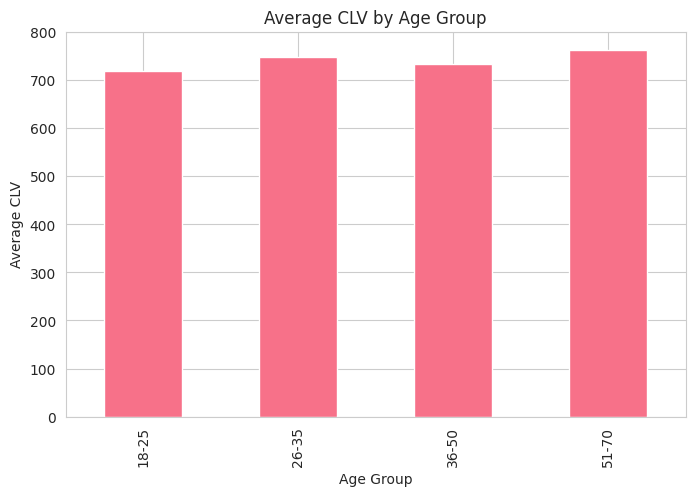

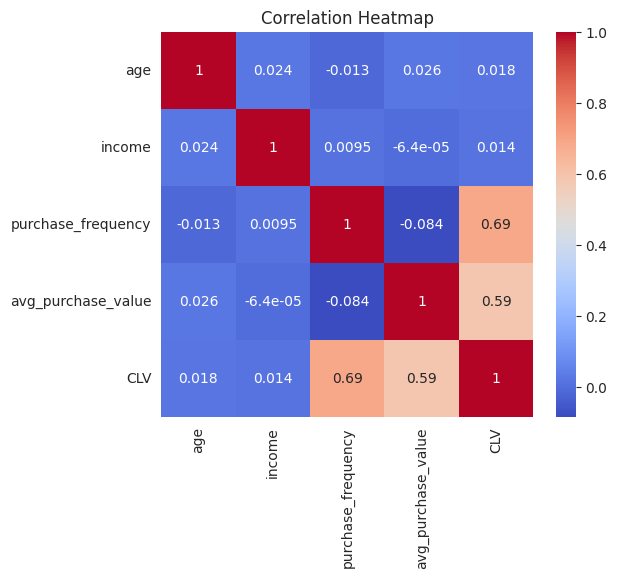


Key Findings:
1. The top 10% of customers contribute 18.8% of total CLV.
2. Income shows a 0.014 correlation with CLV.
3. The 51-70 age group shows the highest average CLV ($762.69).
4. Customers with higher purchase frequency tend to have higher CLV.

Recommendations:
- Focus marketing on top 10% of customers through loyalty programs.
- Target 51-70 age group for acquisition campaigns.
- Encourage repeat purchases to reduce churn risk.
- Personalize offers based on purchase frequency and income.



In [87]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# TODO: Calculate customer lifetime value (CLV)
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency)

max_frequency = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)
customers['CLV'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk'])

print("=" * 60)
print("CLV Statistics:")
print(f"Mean CLV: ${customers['CLV'].mean():.2f}")
print(f"Median CLV: ${customers['CLV'].median():.2f}")
print(f"Max CLV: ${customers['CLV'].max():.2f}")
print(f"Min CLV: ${customers['CLV'].min():.2f}")

# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70
age_bins = [18, 26, 36, 51, 71]
age_labels = ['18-25', '26-35', '36-50', '51-70']
customers['age_group'] = pd.cut(customers['age'], bins=age_bins, labels=age_labels, right=False)

print("\n" + "=" * 60)
print("Age Group Distribution:")
print(customers['age_group'].value_counts().sort_index())

# TODO: For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV
age_group_stats = customers.groupby('age_group').agg(
    num_customers=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
).reindex(age_labels)

print("\n" + "=" * 60)
print("TODO3: Statistics by Age Group:")
print(age_group_stats)


# TODO: Identify top 10% of customers by CLV

top_10_percent_threshold = customers['CLV'].quantile(0.90)
top_customers = customers[customers['CLV'] >= top_10_percent_threshold]

print("\n" + "=" * 60)
print(f"Top 10% CLV Threshold: ${top_10_percent_threshold:.2f}")
print(f"Number of customers in top 10%: {len(top_customers)}")
print(f"Total CLV from top 10%: ${top_customers['CLV'].sum():.2f}")
print(f"Percentage of total CLV: {(top_customers['CLV'].sum() / customers['CLV'].sum() * 100):.1f}%")

print("\nTODO4: Top 10 Customers by CLV:")
print(top_customers.nlargest(10, 'CLV')[['age', 'age_group', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']])

# TODO: Create visualizations:
#       1. Scatter plot of income vs CLV (color by age group)
#       2. Bar chart of average CLV by age group
#       3. Correlation heatmap
sns.set_style("whitegrid")

# 1. Income vs CLV (scatter plot)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group'
)

plt.title("Income vs CLV by Age Group")
plt.xlabel("Income")
plt.ylabel("CLV")

plt.show()


# 2. Bar chart: Average CLV by age group

avg_clv_by_age = customers.groupby('age_group')['CLV'].mean()

plt.figure(figsize=(8, 5))

avg_clv_by_age.plot(kind='bar')

plt.title("Average CLV by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average CLV")

plt.show()


# 3. Correlation heatmap

plt.figure(figsize=(6, 5))

correlation = customers[
    ['age', 'income', 'purchase_frequency',
     'avg_purchase_value', 'CLV']
].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

# TODO: Write a brief analysis paragraph (as a markdown cell)
#       summarizing key findings and recommendations

print(f"""
Key Findings:
1. The top 10% of customers contribute {(top_customers['CLV'].sum() / customers['CLV'].sum() * 100):.1f}% of total CLV.
2. Income shows a {correlation.loc['income', 'CLV']:.3f} correlation with CLV.
3. The {age_group_stats['avg_CLV'].idxmax()} age group shows the highest average CLV (${age_group_stats['avg_CLV'].max():.2f}).
4. Customers with higher purchase frequency tend to have higher CLV.

Recommendations:
- Focus marketing on top 10% of customers through loyalty programs.
- Target {age_group_stats['avg_CLV'].idxmax()} age group for acquisition campaigns.
- Encourage repeat purchases to reduce churn risk.
- Personalize offers based on purchase frequency and income.
""")